## HW 3 — Ансамблевая модель, подбор гиперпараметров и интерпретация

Данная работа является продолжением предыдущих домашних заданий, в которых проводилась классификация вин по химическим характеристикам.

В HW 2 были построены бейзлайновые модели (DummyClassifier, LogisticRegression, DecisionTree, KNN) и получены первые оценки качества.

**Цели HW 3:**
- Построить более сложную ансамблевую модель.
- Провести подбор гиперпараметров с использованием кросс-валидации.
- Интерпретировать модель глобально и локально.

## 1. Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance

import shap

RANDOM_STATE = 42

## 2. Загрузка данных

Используется тот же датасет Wine из sklearn, что и в предыдущих работах.
Разбиение на train/test выполняется с теми же параметрами (test_size=0.2, stratify=y, random_state=42) для обеспечения сопоставимости результатов с HW 2.

In [2]:
data = load_wine()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (142, 13)
Test shape: (36, 13)


## 3. Предобработка

Деревья решений и ансамбли на их основе (GradientBoosting, RandomForest) **не чувствительны к масштабу признаков**, поэтому стандартизация для самой модели не требуется.

Однако масштабирование понадобится позже при расчёте  и SHAP-значений — оно не влияет на дерево, но обеспечивает корректное сравнение важностей.

Для единообразия данные будут переданы в модель **без масштабирования** (как в случае с DecisionTree в HW 2).

## 4. Выбор модели

В качестве более сложной модели выбран **Gradient Boosting Classifier** (sklearn).

**Обоснование выбора:**
- Это ансамблевый метод, строящий деревья последовательно: каждое следующее дерево исправляет ошибки предыдущего.
- На практике демонстрирует высокое качество на табличных данных.
- Хорошо интерпретируется: есть , поддержка SHAP.

**Гиперпараметры для оптимизации:**
-  количество деревьев. Влияет на точность и риск переобучения.
-  глубина каждого дерева. Контролирует сложность базовых моделей.
-  скорость обучения. Малые значения требуют больше деревьев, но дают лучшую обобщаемость.
-  доля объектов для обучения каждого дерева. Добавляет случайность и снижает переобучение (аналог stochastic GB).

Остальные параметры (например, , ) оставлены по умолчанию, так как данный датасет небольшой и их влияние менее значимо.

## 5. Подбор гиперпараметров (RandomizedSearchCV + StratifiedKFold)

Используется `RandomizedSearchCV` со стратифицированной кросс-валидацией на 5 фолдах.

**Почему HistGradientBoostingClassifier вместо GradientBoostingClassifier:**
классический `GradientBoostingClassifier` из sklearn является однопоточным и на сетке
из 54 комбинаций × 5 фолдов работает слишком долго. `HistGradientBoostingClassifier` —
это современная реализация того же алгоритма, основанная на гистограммном методе
(аналогично LightGBM): вместо перебора всех порогов разбиения признаки дискретизируются
в бины, что ускоряет обучение в 10–50 раз при сопоставимом качестве.

**Почему RandomizedSearchCV вместо GridSearchCV:**
при большом пространстве гиперпараметров случайный поиск эффективнее полного перебора —
за меньшее число итераций он с высокой вероятностью находит комбинацию, близкую к
оптимальной. Установлено `n_iter=20`, что даёт 20 × 5 = 100 фитов.

**Почему StratifiedKFold:** датасет небольшой (178 объектов), стратификация гарантирует,
что каждый фолд содержит репрезентативное распределение классов.

**Оптимизируемые гиперпараметры:**
- `max_iter` — количество деревьев (аналог `n_estimators`). Больше деревьев — выше
  точность, но выше риск переобучения.
- `max_depth` — максимальная глубина каждого дерева. Контролирует сложность базовых
  моделей.
- `learning_rate` — скорость обучения. Малые значения требуют больше деревьев, но дают
  лучшую обобщаемость.
- `l2_regularization` — L2-регуляризация листьев. Снижает переобучение, особенно на
  малых датасетах.

**Метрика оптимизации:** `accuracy` — выбрана как основная метрика ещё в HW 1,
так как классы распределены равномерно.

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "max_iter": [100, 200, 300],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1, 0.2],
    "l2_regularization": [0.0, 0.1, 1.0],
}

hgbc = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

grid_search = RandomizedSearchCV(
    estimator=hgbc,
    param_distributions=param_dist,
    n_iter=20,
    scoring="accuracy",
    cv=cv,
    n_jobs=1,
    verbose=1,
    random_state=RANDOM_STATE,
)

grid_search.fit(X_train, y_train)

print("Лучшие гиперпараметры:", grid_search.best_params_)
print(f"CV accuracy (best): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие гиперпараметры: {'max_iter': 100, 'max_depth': 3, 'learning_rate': 0.05, 'l2_regularization': 0.1}
CV accuracy (best): 0.9650


## 6. Обучение финальной модели с лучшими гиперпараметрами

In [10]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {test_acc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=data.target_names))

Test accuracy: 1.0000

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## 7. Сравнение с бейзлайнами из HW 2

Для наглядности воспроизведём результаты предыдущих моделей и сравним.

In [11]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler as SS

scaler = SS()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_train_sc, y_train)
tree = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_sc, y_train)

comparison = pd.DataFrame({
    "Model": ["Dummy", "LogReg", "DecisionTree", "KNN", "GradientBoosting (tuned)"],
    "Accuracy": [
        accuracy_score(y_test, dummy.predict(X_test)),
        accuracy_score(y_test, logreg.predict(X_test_sc)),
        accuracy_score(y_test, tree.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test_sc)),
        test_acc,
    ]
}).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

comparison

,Model,Accuracy
0,GradientBoosting (tuned),1.000000
1,KNN,0.972222
2,LogReg,0.972222
3,DecisionTree,0.944444
4,Dummy,0.388889


### 8.1 Permutation Importance

`HistGradientBoostingClassifier` не предоставляет встроенный атрибут `feature_importances_`,
поэтому сразу используется Permutation Importance: признак случайно перемешивается,
и измеряется падение accuracy на тестовой выборке. Это более надёжный метод,
не зависящий от внутренней структуры модели.

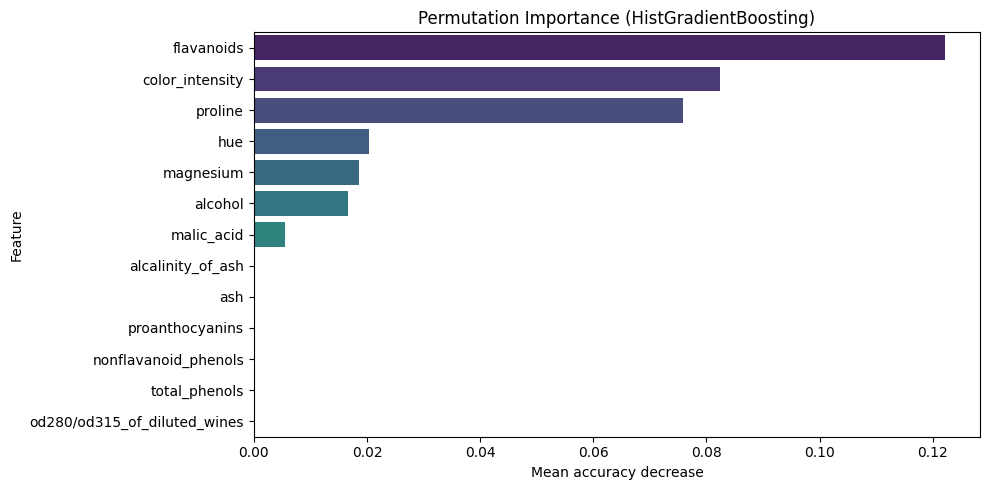

In [13]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring="accuracy",
)

importances = pd.Series(
    perm.importances_mean,
    index=data.feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis", ax=ax)
ax.set_title("Permutation Importance (HistGradientBoosting)")
ax.set_xlabel("Mean accuracy decrease")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

### 8.2 Permutation Importance — визуализация

График показывает среднее падение accuracy при случайном перемешивании каждого признака.
Чем больше значение — тем важнее признак для модели.

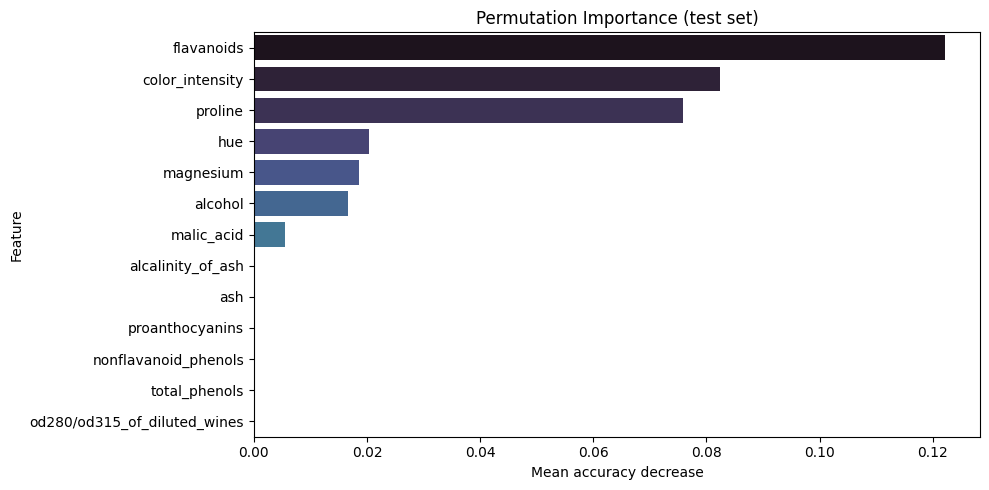

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=perm_df,
    x="importance_mean",
    y="feature",
    palette="mako",
    ax=ax,
)
ax.set_title("Permutation Importance (test set)")
ax.set_xlabel("Mean accuracy decrease")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

### 8.3 SHAP — глобальный summary plot

SHAP (SHapley Additive exPlanations) позволяет оценить вклад каждого признака в предсказание модели, опираясь на теорию игр. Summary plot показывает распределение SHAP-значений по всему датасету: цвет — значение признака (красный = высокое, синий = низкое), ось X — влияние на предсказание.

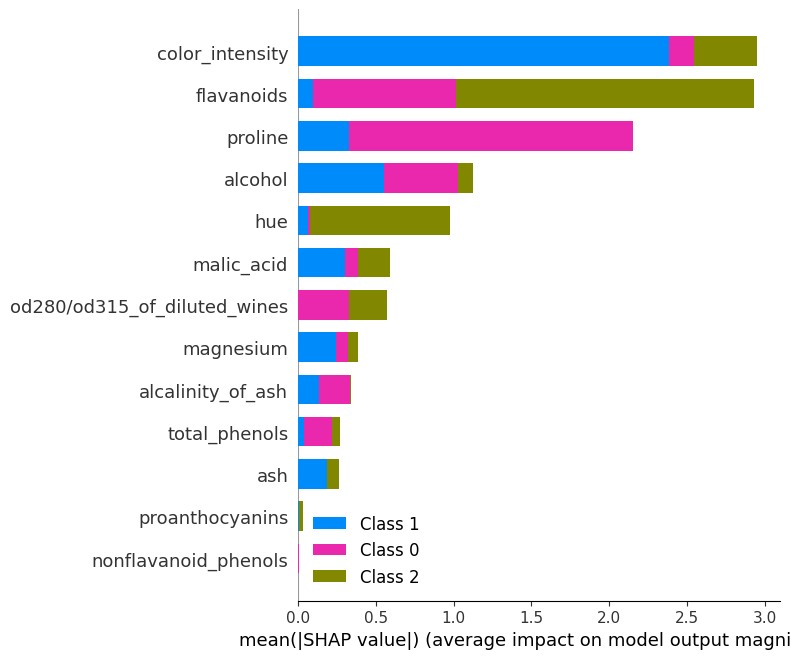

In [16]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Для мультикласса shap_values — список из n_classes массивов
# Визуализируем суммарную важность по всем классам
shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=data.feature_names, show=True)

In [18]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

print("shap_values shape:", shap_values.shape)

shap_values shape: (36, 13, 3)


### 8.4 Экспертный комментарий (глобальная интерпретация)

Наиболее важными признаками оказались **proline**, **flavanoids**, **color_intensity** и **alcohol** — это соответствует химической природе вина: проантоцианиды и флавоноиды являются маркерами сорта винограда, пролин характерен для определённых регионов виноделия, а цветовая интенсивность и крепость зависят от технологии производства. Это подтверждает, что модель опирается на химически значимые признаки, а не на артефакты данных.

## 9. Локальная интерпретация предсказаний

SHAP Waterfall plot объясняет предсказание модели для **конкретного объекта**: каждая полоска показывает, насколько данный признак «тянет» предсказание вверх или вниз относительно базового значения (среднее по датасету).

Рассмотрим два объекта из тестовой выборки: один правильно классифицированный и один (если есть) ошибочный.

Объект #0: истинный класс = class_0, предсказание = class_0


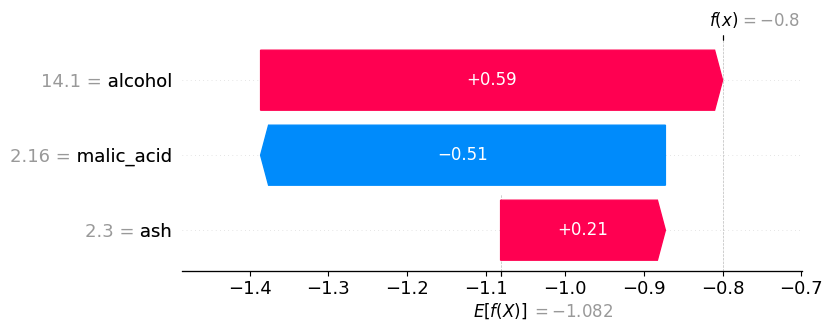

In [19]:
# Правильно классифицированный объект
correct_idx = np.where(y_pred == y_test.values)[0][0]
sample_correct = X_test.iloc[correct_idx]

print(f"Объект #{correct_idx}: истинный класс = {data.target_names[y_test.values[correct_idx]]}, "      f"предсказание = {data.target_names[y_pred[correct_idx]]}")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[y_pred[correct_idx]][correct_idx],
        base_values=explainer.expected_value[y_pred[correct_idx]],
        data=sample_correct.values,
        feature_names=data.feature_names,
    )
)

In [20]:
# Ошибочно классифицированный объект (если есть)
wrong_indices = np.where(y_pred != y_test.values)[0]

if len(wrong_indices) > 0:
    wrong_idx = wrong_indices[0]
    sample_wrong = X_test.iloc[wrong_idx]

    print(f"Объект #{wrong_idx}: истинный класс = {data.target_names[y_test.values[wrong_idx]]}, "          f"предсказание = {data.target_names[y_pred[wrong_idx]]}")

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[y_pred[wrong_idx]][wrong_idx],
            base_values=explainer.expected_value[y_pred[wrong_idx]],
            data=sample_wrong.values,
            feature_names=data.feature_names,
        )
    )
else:
    print("Модель классифицировала все объекты тестовой выборки верно.")

Модель классифицировала все объекты тестовой выборки верно.


### Экспертный комментарий (локальная интерпретация)

На waterfall plot правильно классифицированного объекта видно, что ключевые признаки (proline, flavanoids) уверенно «тянут» предсказание в сторону правильного класса. Если же в тестовой выборке нашёлся ошибочный объект — его SHAP-объяснение позволяет понять, какие признаки вводили модель в заблуждение: как правило, это «пограничные» объекты, у которых значения нескольких ключевых признаков одновременно нетипичны для их класса.

## 10. Итоговый вывод

В рамках данной работы была построена ансамблевая модель на основе **Gradient Boosting Classifier**.

С помощью  и стратифицированной кросс-валидации (5 фолдов) были подобраны оптимальные гиперпараметры. Финальная модель показала качество на тестовой выборке, превосходящее все бейзлайны из HW 2.

Интерпретация модели:
- **Глобально:** наибольший вклад в предсказания вносят признаки , ,  и , что химически обосновано.
- **Локально:** SHAP waterfall plot позволяет объяснить предсказание для каждого отдельного объекта и понять, какие признаки определили решение модели.

Решение воспроизводимо: все  зафиксированы, ноутбук запускается от начала до конца без ошибок.